In [1]:
from core.analysis_config import AnalysisConfig
from core.reference import Reference
from core.observable import ObsType
from utils.analyzer import Analyzer
from utils.plotting import PlotLimits, CMSPlotStyle
from utils.workdirectory import WorkDirectory
from pathlib import Path
PROJECTDIR = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/')
CONFIG = AnalysisConfig('bamboo_hh/config/disc_study_new.yml')
OUTDIR = Path('disc_study/figs/distributions')
make_llr_ref = lambda llr_name: Reference.from_parts(['SL_4j_resolved'], [llr_name])
plot_style = CMSPlotStyle(figsize=(8,6), label_fs=18, tick_fs=18, legend_fs=18, cms_fs=18)

Welcome to JupyROOT 6.30/02


In [2]:
from utils.plotting import PlotLimits, CMSPlotStyle, hist_to_numpy, format_label_for_plt, save_fig, hist_to_numpy
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import mplhep
plt.style.use(mplhep.style.CMS)

def plot_log_sig_bkg(analyzer, ref, plot_style = CMSPlotStyle(), plot_limits: PlotLimits = None, eras=None):
    signal_hist, background_hist = analyzer.get_signal_background(ref, eras=eras)
    plot_style, plot_limits = analyzer._build_ax_labels_limits(ref, plot_style, plot_limits=plot_limits)
    save_path = OUTDIR / f"{ref.name}_log.pdf"
    
    hists = [signal_hist, background_hist]
    legend = ['Signal', 'Background']
    colors = ['blue', 'red']
    
    # if ObsType.get_dimensionality(ref) == 1:
    hist_values, hist_edges = [], []
    for hist in hists:
        vals, edges = hist_to_numpy(hist)
        hist_values.append(vals)
        hist_edges.append(edges[0])
    
    plot_style.ylabel = 'Events'
    # Auto-scale y if not specified
    # plot_limits.ymin = plot_limits.ymin or 0
    # plot_limits.ymax = plot_limits.ymax or max(vals.max() for vals in hist_values) * 1.2
        
    values = hist_values
    edges = hist_edges
    fig, ax = plot_style.setup_figure()
    for i in range(len(values)):
        values_i = values[i]
        color_i = colors[i]
        legend_i = legend[i]
        edges_i = edges[i]
        ax.step(edges_i[:-1], values_i, where='post', color=color_i, linewidth=2.0, label=legend_i)
        ax.fill_between(edges_i[:-1], values_i, step='post', color=color_i, alpha=0.2)

    xlabel = format_label_for_plt(plot_style.xlabel)
    ylabel = format_label_for_plt(plot_style.ylabel)
    print(xlabel)
    ax.set_xlabel(xlabel, fontsize=plot_style.label_fs)
    ax.set_ylabel(ylabel, fontsize=plot_style.label_fs)
    ax.tick_params(axis='both', which='major', labelsize=plot_style.tick_fs)
    # ax.set_xlim(plot_limits.xmin, plot_limits.xmax)
    # ax.set_ylim(plot_limits.ymin, plot_limits.ymax)
    
    ax.set_yscale('log')

    ax.grid(True)
    ax.legend(fontsize=plot_style.legend_fs, loc="upper right", frameon=True)

    plot_style.add_cms_text(ax)
    fig.tight_layout()
    save_fig(plt, save_path)
    plt.show()

In [3]:
%config InlineBackend.figure_format = 'retina'

In [4]:
subprojectdir = PROJECTDIR / 'crtd_final'
crtd_dirs = [d for d in subprojectdir.iterdir() if d.is_dir() and 'LLR_cmb' in d.name]
for i, d in enumerate(crtd_dirs): print(i, d.name)

0 LLR_cmb10_b0
1 LLR_cmb10_b1
2 LLR_cmb10_b2
3 LLR_cmb11
4 LLR_cmb12to15
5 LLR_cmb2to3
6 LLR_cmb4
7 LLR_cmb5_b0
8 LLR_cmb5_b1
9 LLR_cmb5_b2
10 LLR_cmb6_b0
11 LLR_cmb6_b1
12 LLR_cmb6_b2
13 LLR_cmb6_b3
14 LLR_cmb7_b0
15 LLR_cmb7_b1
16 LLR_cmb7_b2
17 LLR_cmb7_b3
18 LLR_cmb7_b4
19 LLR_cmb8_b0
20 LLR_cmb8_b1
21 LLR_cmb8_b2
22 LLR_cmb8_b3
23 LLR_cmb8_b4
24 LLR_cmb9_b0
25 LLR_cmb9_b1
26 LLR_cmb9_b2
27 LLR_cmb9_b3


In [5]:
ref_best = make_llr_ref('jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_jj_l_dPhi_x_blnu_bl_mInv_x_WW_pt_x_bjets_mbb_x_bjets_dPhi_llr')

ref_2var = make_llr_ref('jj_l_dR_x_bjets_pt_bb_llr')
ref_3var = make_llr_ref('jj_l_dR_x_WW_mInv_x_bjets_pt_bb_llr')
ref_4var = make_llr_ref('jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_WW_pt_llr')
ref_5var = make_llr_ref('jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_WW_pt_x_bjets_dPhi_llr')
ref_6var = make_llr_ref('jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_bjets_dR_x_WW_pt_x_bjets_dPhi_llr')
ref_7var = make_llr_ref('jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_bjets_dR_x_blnu_bl_mInv_x_WW_pt_x_bjets_dPhi_llr')
ref_8var = make_llr_ref('jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_bjets_dR_x_blnu_bl_mInv_x_WW_pt_x_bjets_mbb_x_bjets_dPhi_llr')

$LLR_{comp}(\Delta\!R(jj,\ell),p_{T}^{bb})$
Figure saved to disc_study/figs/distributions/SL_4j_resolved___jj_l_dR_x_bjets_pt_bb_llr.pdf


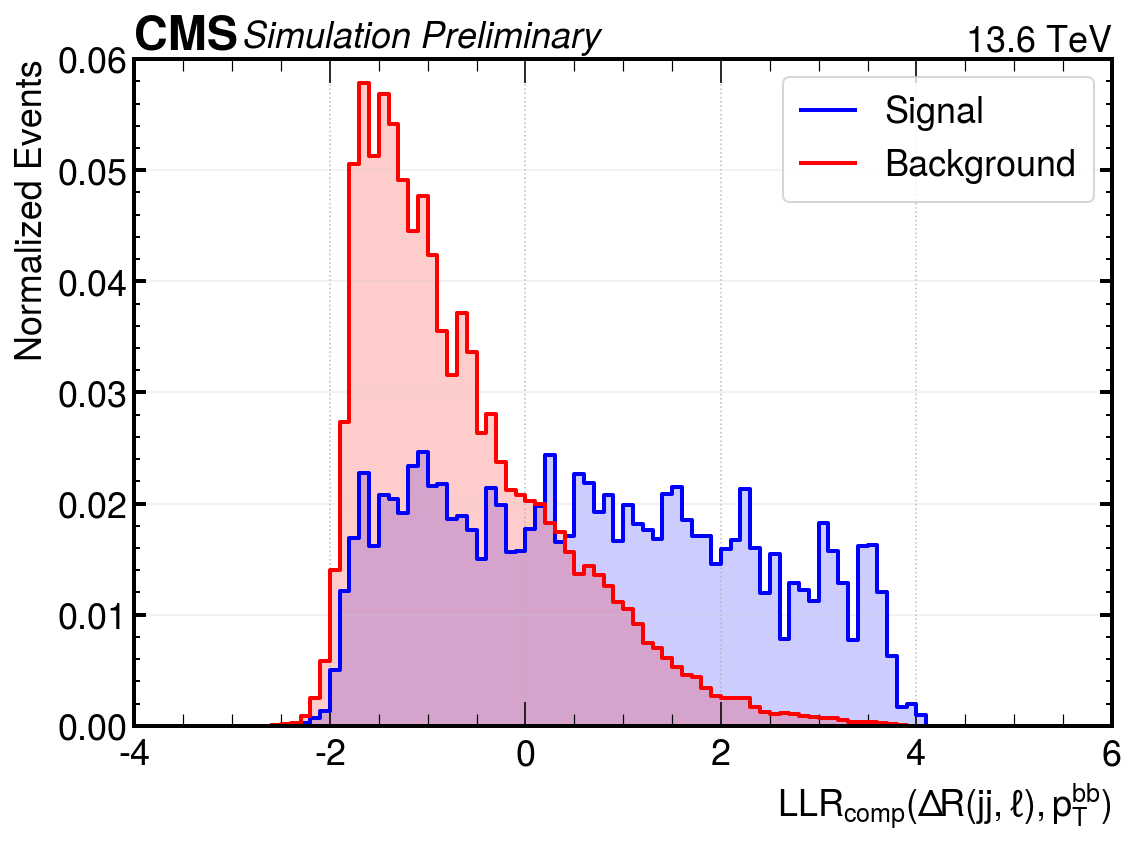

$LLR_{comp}(\Delta\!R(jj,\ell),m^{WW},p_{T}^{bb})$
Figure saved to disc_study/figs/distributions/SL_4j_resolved___jj_l_dR_x_WW_mInv_x_bjets_pt_bb_llr.pdf


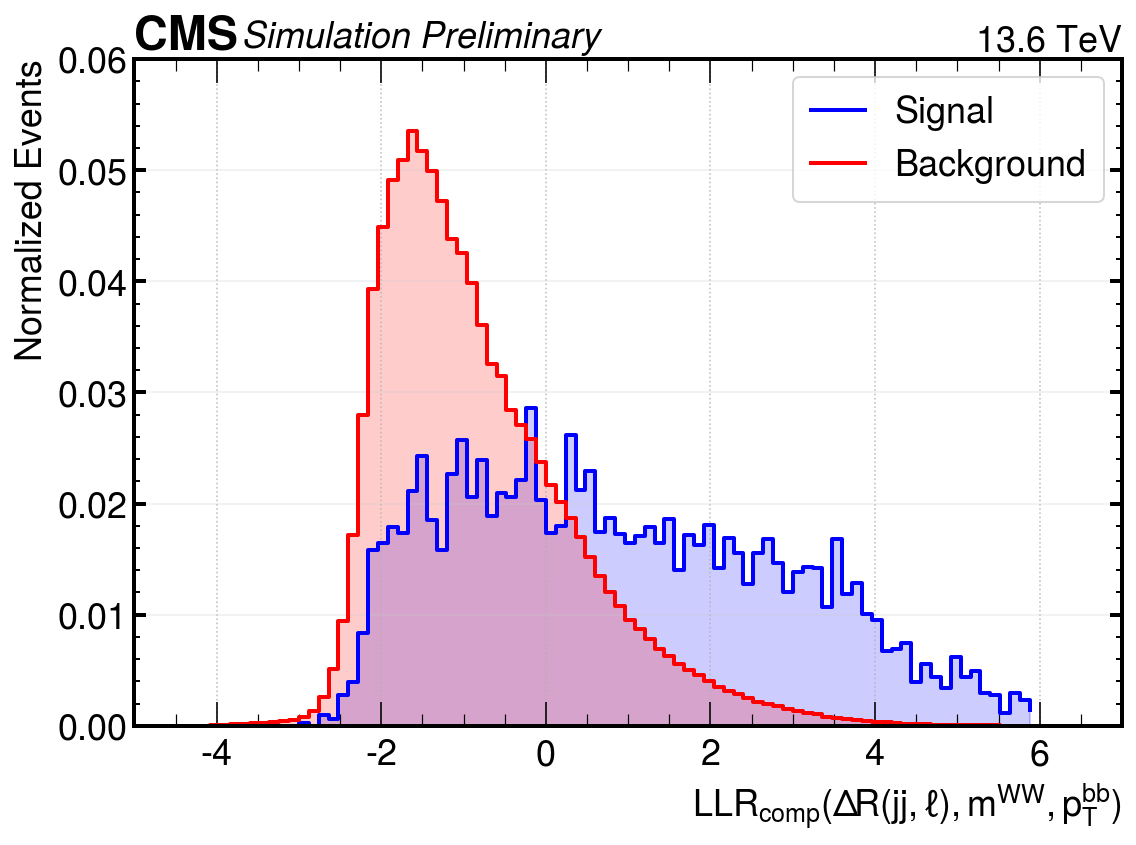

In [7]:
wd = WorkDirectory(crtd_dirs[5])
llr_analyzer = Analyzer(wd, CONFIG, OUTDIR)
llr_analyzer.plot_sig_bkg(ref_2var, plot_style, PlotLimits(xmin=-4, xmax=6, ymax=0.06))
llr_analyzer.plot_sig_bkg(ref_3var, plot_style, PlotLimits(xmin=-5, xmax=7, ymax=0.06))

$LLR_{comp}(\Delta\!R(jj,\ell),m^{WW},p_{T}^{bb},p_{T}^{WW})$
Figure saved to disc_study/figs/distributions/SL_4j_resolved___jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_WW_pt_llr.pdf


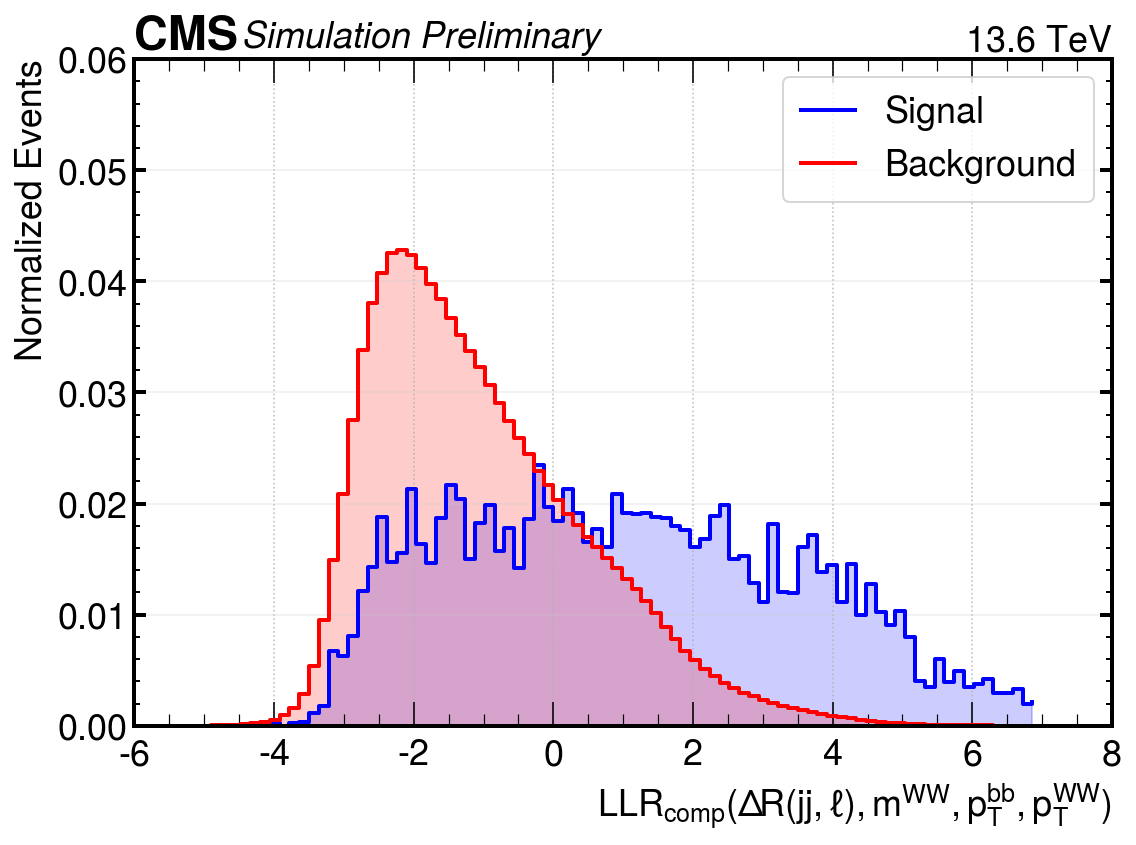

In [8]:
wd = WorkDirectory(crtd_dirs[6])
llr_analyzer = Analyzer(wd, CONFIG, OUTDIR)
llr_analyzer.plot_sig_bkg(ref_4var, plot_style, PlotLimits(xmin=-6, xmax=8, ymax=0.06))

$LLR_{comp}(\Delta\!R(jj,\ell),m^{WW},p_{T}^{bb},p_{T}^{WW},\Delta\phi(b,b))$
Figure saved to disc_study/figs/distributions/SL_4j_resolved___jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_WW_pt_x_bjets_dPhi_llr.pdf


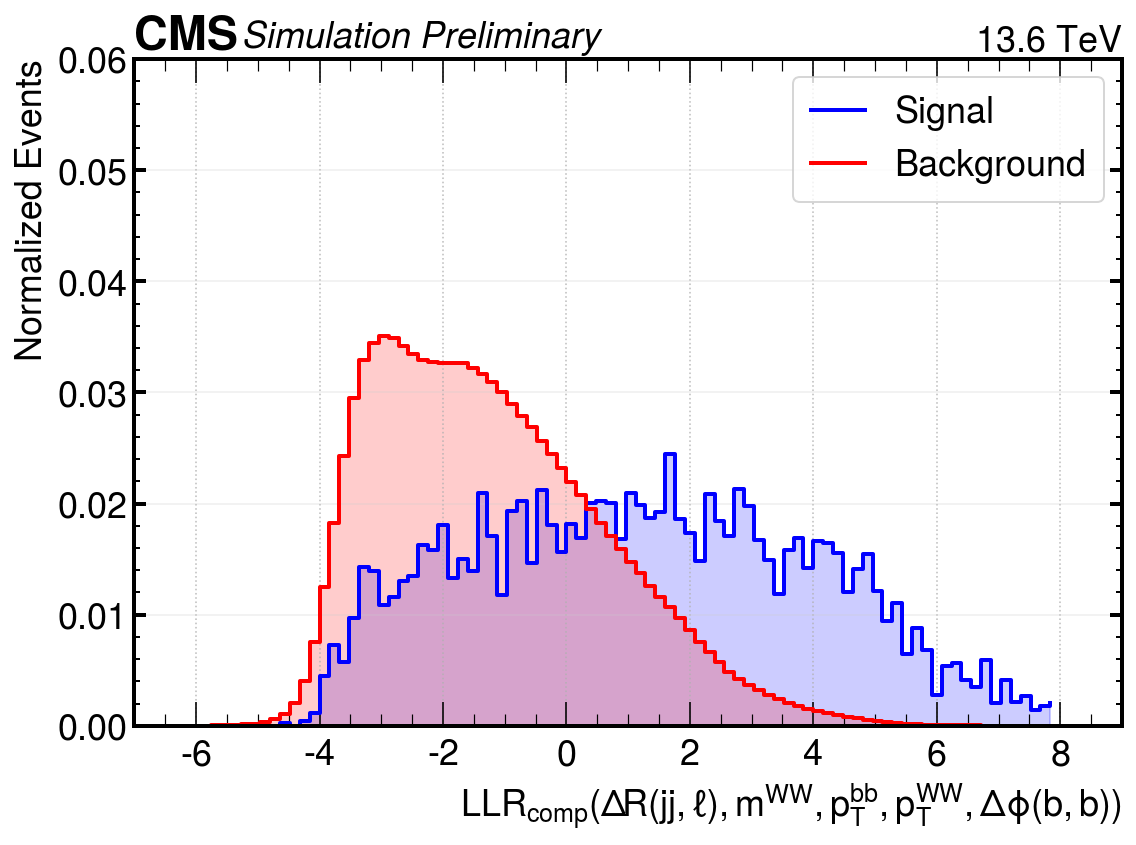

In [9]:
wd = WorkDirectory(crtd_dirs[7])
llr_analyzer = Analyzer(wd, CONFIG, OUTDIR)
llr_analyzer.plot_sig_bkg(ref_5var, plot_style, PlotLimits(xmin=-7, xmax=9, ymax=0.06))

$LLR_{comp}(\Delta\!R(jj,\ell),m^{WW},p_{T}^{bb},\Delta\!R(b,b),p_{T}^{WW},\Delta\phi(b,b))$
Figure saved to disc_study/figs/distributions/SL_4j_resolved___jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_bjets_dR_x_WW_pt_x_bjets_dPhi_llr.pdf


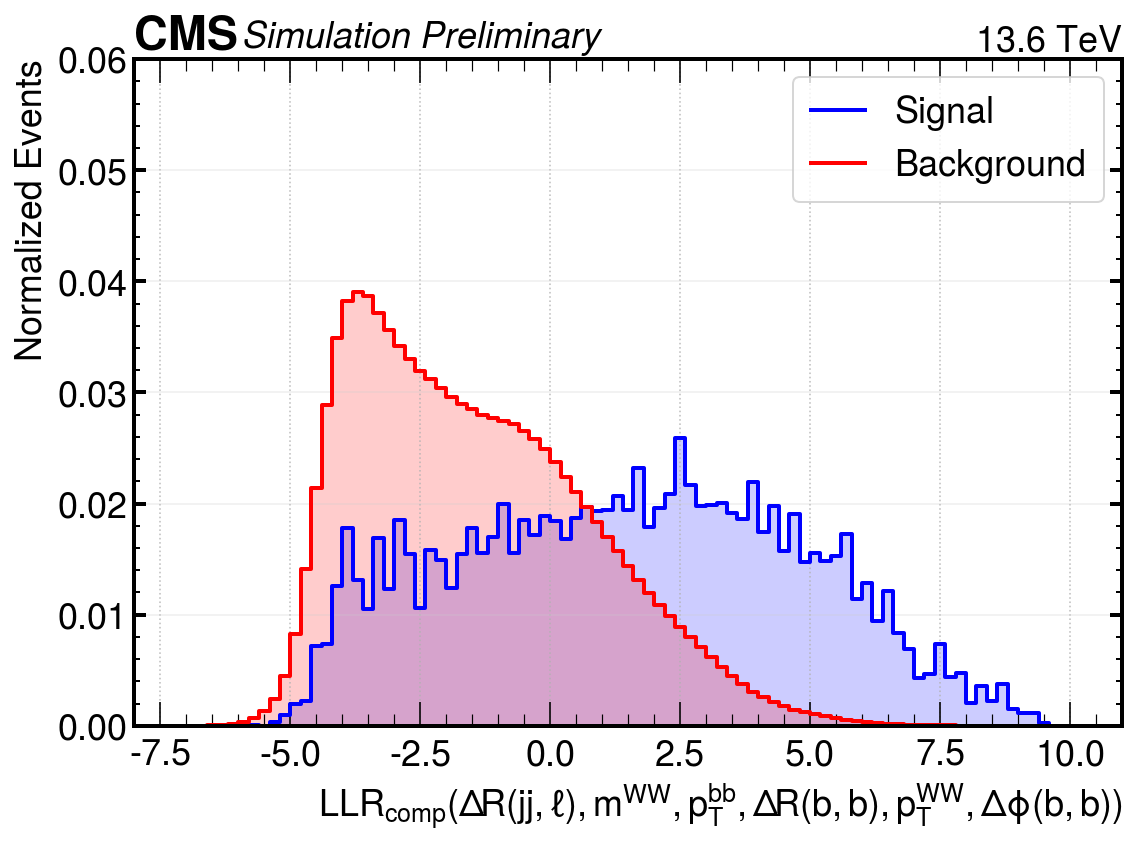

In [10]:
wd = WorkDirectory(crtd_dirs[10])   # 10 to 13
llr_analyzer = Analyzer(wd, CONFIG, OUTDIR)
llr_analyzer.plot_sig_bkg(ref_6var, plot_style, PlotLimits(xmin=-8, xmax=11, ymax=0.06))

$LLR_{comp}(\Delta\!R(jj,\ell),m^{WW},p_{T}^{bb},\Delta\!R(b,b),m_{bl}^{t_{lep}},p_{T}^{WW},\Delta\phi(b,b))$
Figure saved to disc_study/figs/distributions/SL_4j_resolved___jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_bjets_dR_x_blnu_bl_mInv_x_WW_pt_x_bjets_dPhi_llr.pdf


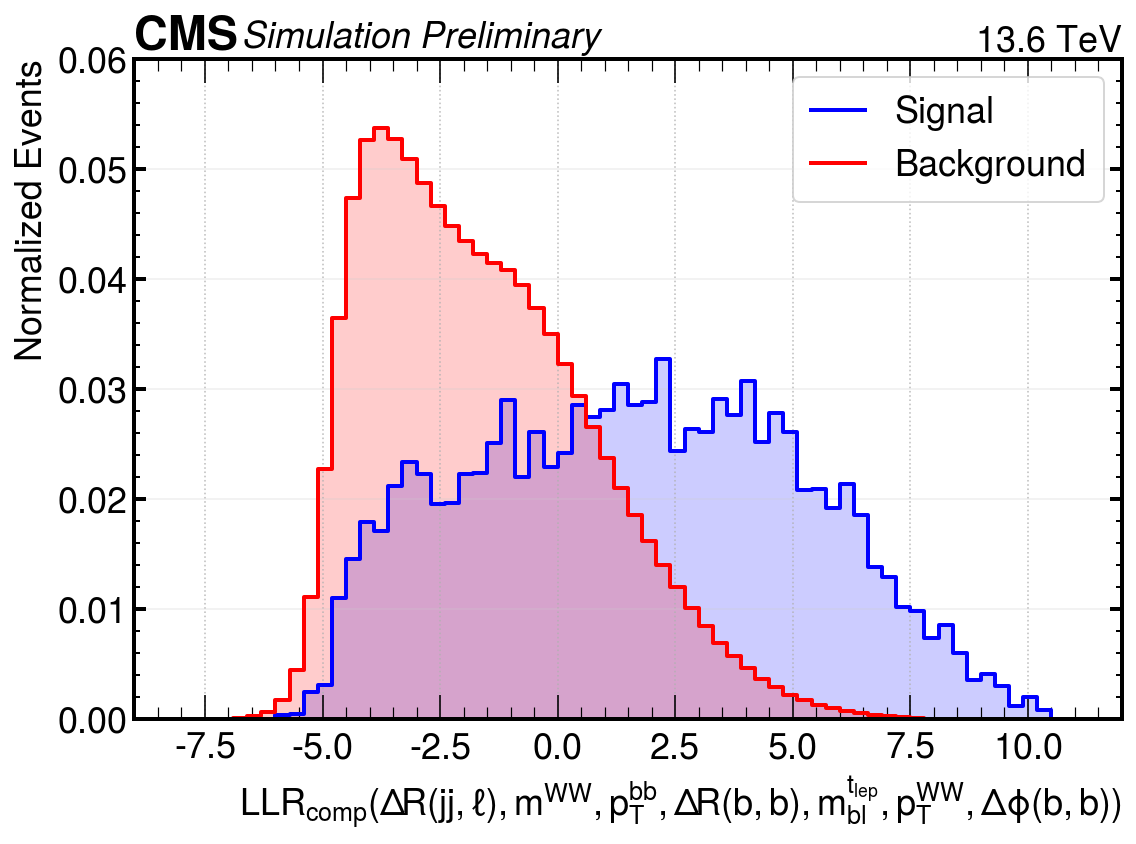

In [11]:
wd = WorkDirectory(crtd_dirs[15])   # 14 to 18
llr_analyzer = Analyzer(wd, CONFIG, OUTDIR)
llr_analyzer.plot_sig_bkg(ref_7var, plot_style, PlotLimits(xmin=-9, xmax=12, ymax=0.06))

$LLR_{comp}(\Delta\!R(jj,\ell),m^{WW},p_{T}^{bb},\Delta\!R(b,b),m_{bl}^{t_{lep}},p_{T}^{WW},m^{bb},\Delta\phi(b,b))$
Figure saved to disc_study/figs/distributions/SL_4j_resolved___jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_bjets_dR_x_blnu_bl_mInv_x_WW_pt_x_bjets_mbb_x_bjets_dPhi_llr.pdf


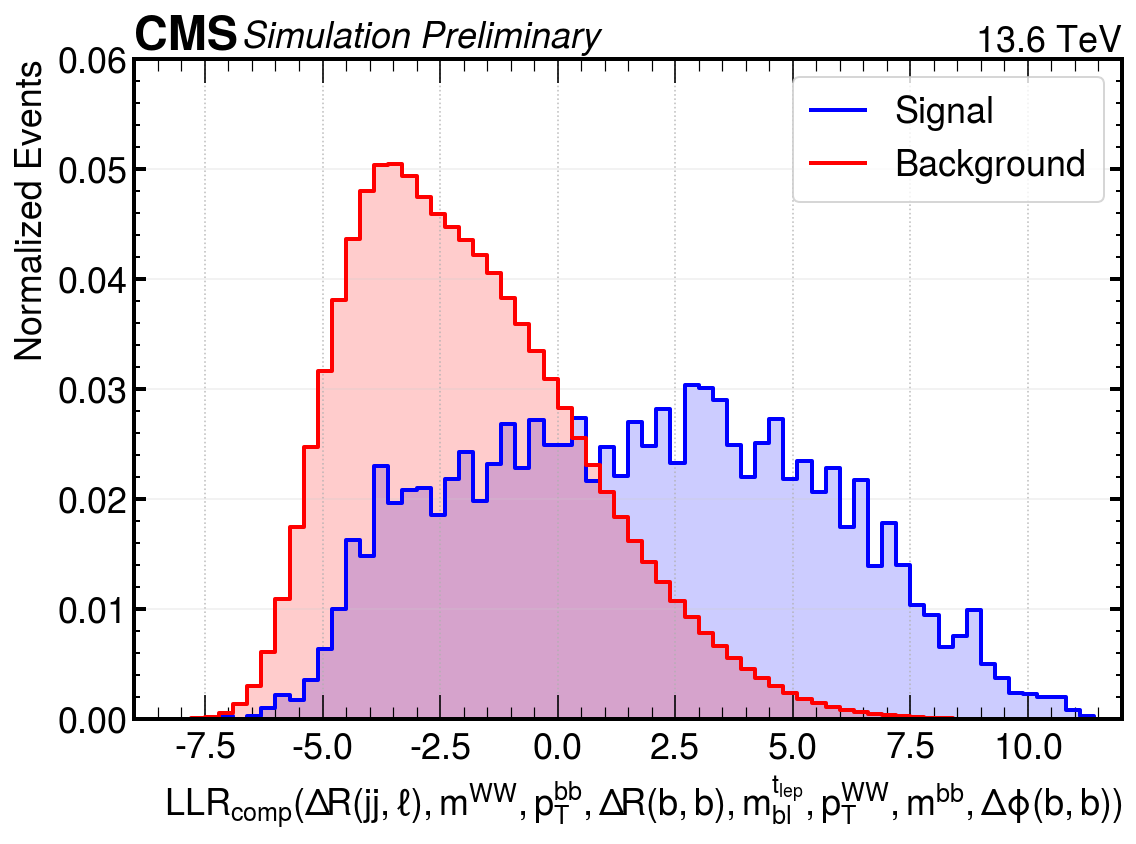

In [13]:
wd = WorkDirectory(crtd_dirs[20])   # 19 to 23
llr_analyzer = Analyzer(wd, CONFIG, OUTDIR)
llr_analyzer.plot_sig_bkg(ref_8var, plot_style, PlotLimits(xmin=-9, xmax=12, ymax=0.06))

### Best llr

SL_4j_resolved___jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_jj_l_dPhi_x_blnu_bl_mInv_x_WW_pt_x_bjets_mbb_x_bjets_dPhi_llr


$LLR_{comp}(\Delta\!R(jj,\ell),m^{WW},p_{T}^{bb},\Delta\phi(jj,\ell),m_{bl}^{t_{lep}},p_{T}^{WW},m^{bb},\Delta\phi(b,b))$
Figure saved to disc_study/figs/distributions/SL_4j_resolved___jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_jj_l_dPhi_x_blnu_bl_mInv_x_WW_pt_x_bjets_mbb_x_bjets_dPhi_llr.pdf


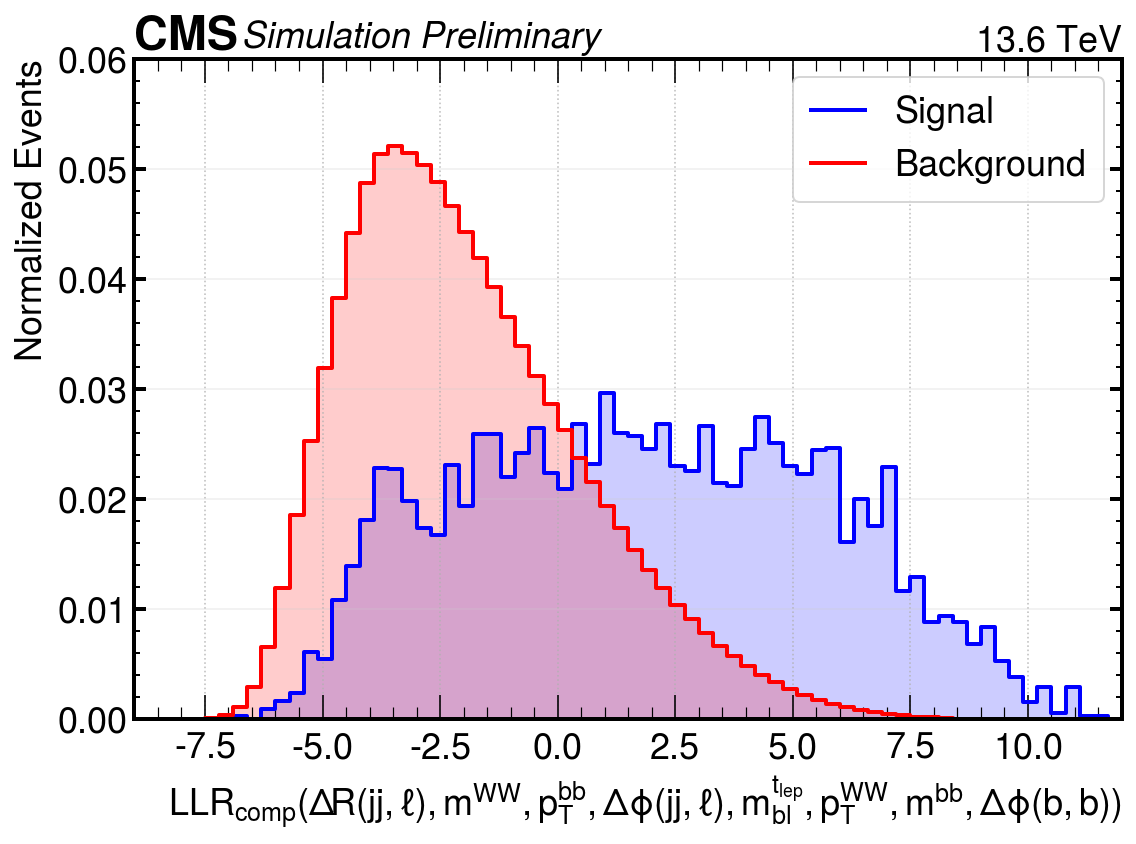

In [14]:
wd = WorkDirectory(crtd_dirs[20])   # 19 to 23
llr_analyzer = Analyzer(wd, CONFIG, OUTDIR)
print(ref_best.name)
llr_analyzer.plot_sig_bkg(ref_best, plot_style, PlotLimits(xmin=-9, xmax=12, ymax=0.06))

$LLR_{fact}(\Delta\!R(jj,\ell),m^{WW},p_{T}^{bb},\Delta\phi(jj,\ell),m_{bl}^{t_{lep}},p_{T}^{WW},m^{bb},\Delta\phi(b,b))$
Figure saved to SL_4j_resolved___jj_l_dR_x_WW_mInv_x_bjets_pt_bb_x_jj_l_dPhi_x_blnu_bl_mInv_x_WW_pt_x_bjets_mbb_x_bjets_dPhi_llr_log.pdf


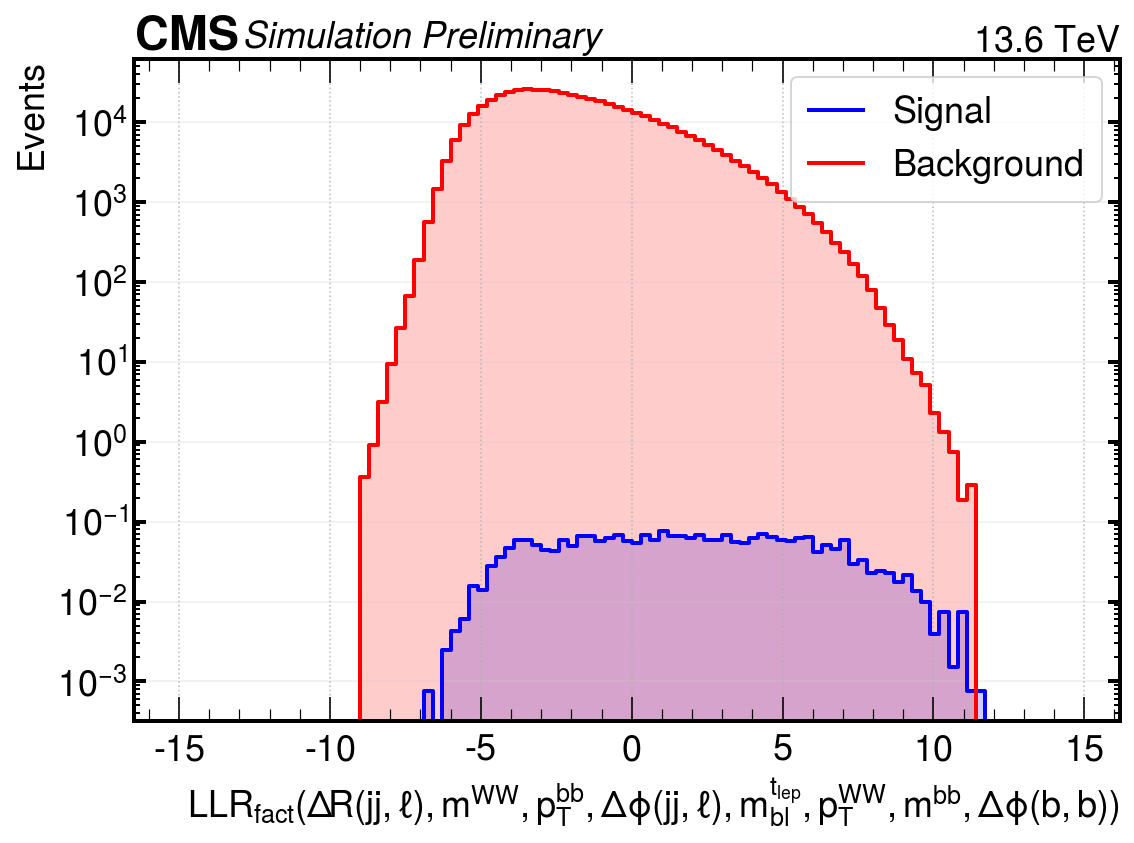

In [ ]:
plot_log_sig_bkg(llr_analyzer, ref_best, plot_style, PlotLimits(xmin=-9, xmax=12))

### NN score distributions

In [ ]:
wd = WorkDirectory('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/NNInf_even_0909')   # 19 to 23
nn_analyzer = Analyzer(wd, CONFIG, outdir=OUTDIR)
for ref in wd.refs:
    print(ref.name)

SL_4j_resolved___multi_HH_ttbar_tW_both__HH
SL_4j_resolved__HH___multi_HH_ttbar_tW_both__HH
SL_4j_resolved___multi_HH_ttbar_tW_both__ttbar
SL_4j_resolved__ttbar___multi_HH_ttbar_tW_both__ttbar
SL_4j_resolved___multi_HH_ttbar_tW_both__tW
SL_4j_resolved__tW___multi_HH_ttbar_tW_both__tW
SL_4j_resolved___multi_HH_ttbar_tW_lrs__HH
SL_4j_resolved__HH___multi_HH_ttbar_tW_lrs__HH
SL_4j_resolved___multi_HH_ttbar_tW_lrs__ttbar
SL_4j_resolved__ttbar___multi_HH_ttbar_tW_lrs__ttbar
SL_4j_resolved___multi_HH_ttbar_tW_lrs__tW
SL_4j_resolved__tW___multi_HH_ttbar_tW_lrs__tW
SL_4j_resolved___multi_HH_ttbar_tW_vars__HH
SL_4j_resolved__HH___multi_HH_ttbar_tW_vars__HH
SL_4j_resolved___multi_HH_ttbar_tW_vars__ttbar
SL_4j_resolved__ttbar___multi_HH_ttbar_tW_vars__ttbar
SL_4j_resolved___multi_HH_ttbar_tW_vars__tW
SL_4j_resolved__tW___multi_HH_ttbar_tW_vars__tW


In [ ]:
hh_ref = Reference('SL_4j_resolved__HH___multi_HH_ttbar_tW_vars__HH')

HH score
Figure saved to disc_study/figs/SL_4j_resolved__HH___multi_HH_ttbar_tW_vars__HH.pdf


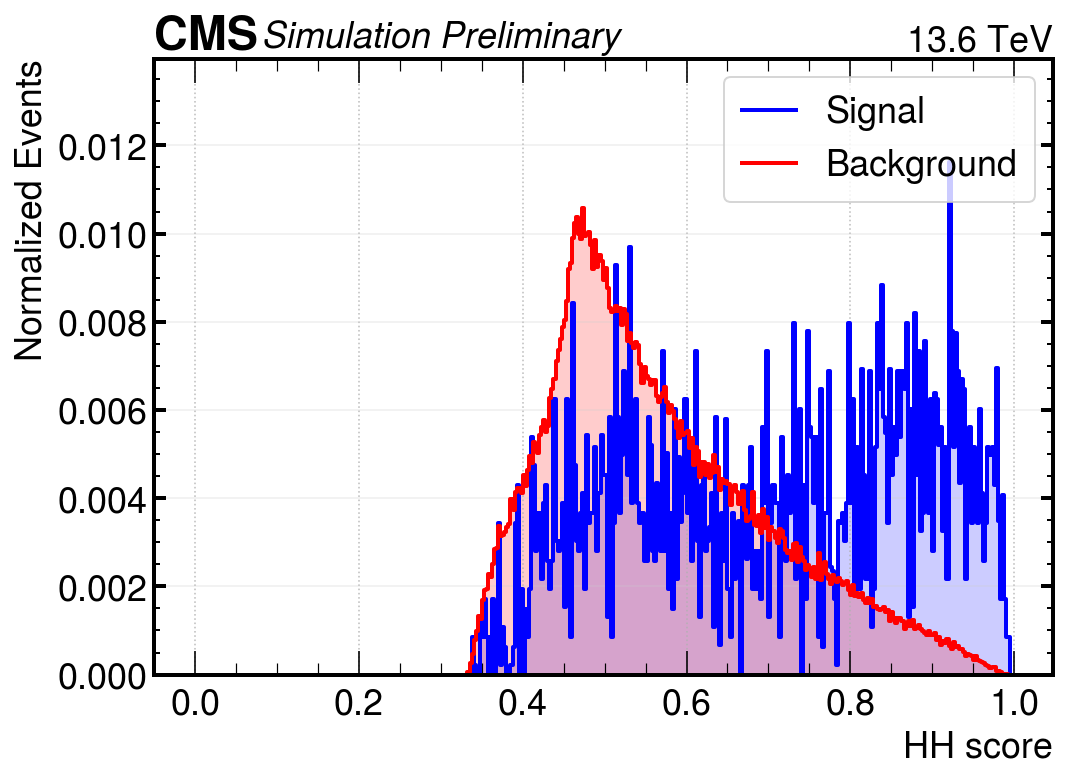

In [ ]:
nn_analyzer.plot_sig_bkg(hh_ref, plot_style)

HH score
Figure saved to disc_study/figs/SL_4j_resolved__HH___multi_HH_ttbar_tW_vars__HH_log.pdf


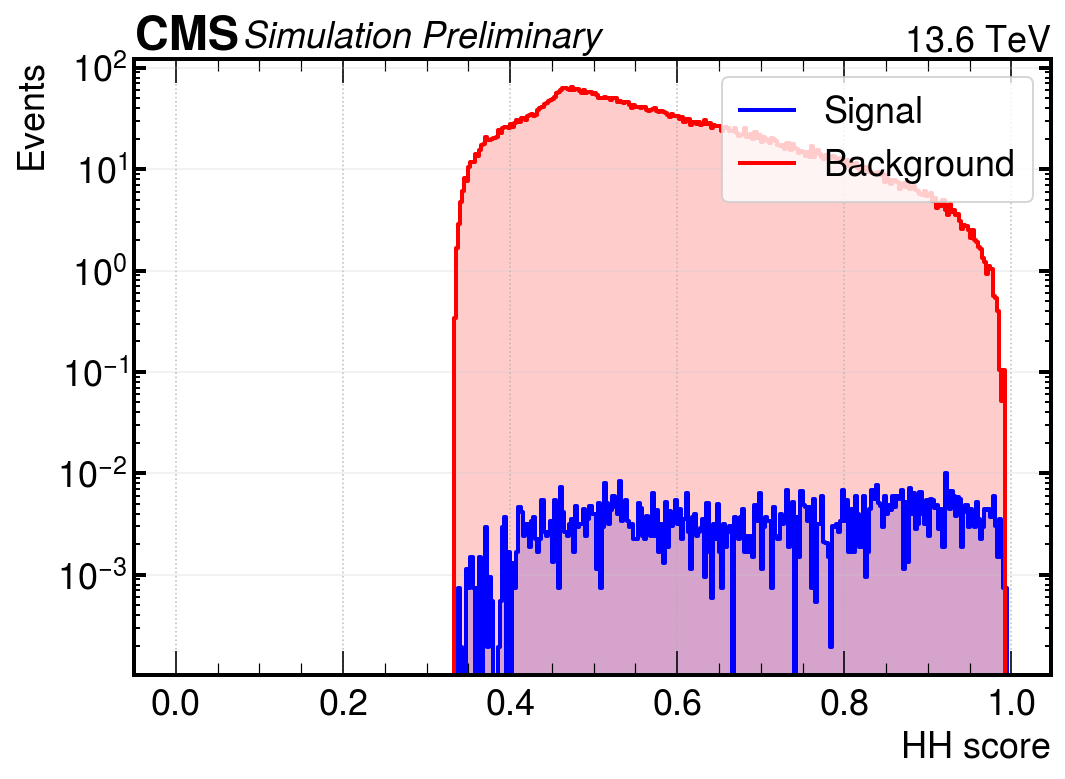

In [ ]:
plot_log_sig_bkg(nn_analyzer, hh_ref, plot_style)